# CD1 · Aula 07 — Laboratório: validação cruzada aninhada (Nested CV)

A **busca em grade** (`GridSearchCV`) você viu hoje por cima: você dá uma grade de valores,
ela varre tudo com validação cruzada e devolve a melhor combinação. Ela ganha a aula
inteira na **próxima aula** — como montar a grade, quanto custa, o que fazer quando ela
explode. Aqui ela entra só como ferramenta: é o que o **laço interno** usa para escolher.

O assunto de hoje é o outro laço. A nota que a busca imprime (`best_score_`) é o **máximo**
de várias tentativas, e o máximo sempre pega um tanto de sorte — então ela não serve como
resposta para *"quanto esperar em dados novos?"*. Você vai ver a maldição do vencedor
acontecer com números, transformar a mesma busca em Nested CV com **uma linha**, refazer o
laço externo à mão para entender o que a linha faz, e medir o otimismo que o Nested remove.

Não é preciso dominar o `GridSearchCV` para fazer este laboratório: os exemplos mostram
tudo o que você precisa dele.

**Como usar.** Antes de cada exercício há uma célula de **exemplo**, já pronta e rodando,
com a mecânica num caso mínimo. Rode o exemplo, entenda, e só então resolva o exercício
logo abaixo. Rode o caderno **de cima para baixo**.

## Parte 0 — Ambiente e dados

In [3]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import (GridSearchCV, cross_val_score,
                                     StratifiedKFold, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

TEAL, VERM, CINZA = "#0F766E", "#B91C1C", "#475569"

df = pd.read_csv("dados_aula07.csv")
X  = df.drop(columns="target").values
y  = df["target"].values

# a grade do dia: 3 valores de C x 3 de gamma = 9 combinacoes
GRADE = {"svc__C": [0.1, 1, 10], "svc__gamma": [0.01, 0.1, 1]}

def novo_pipe():
    """Um Pipeline NOVO a cada chamada: padroniza dentro de cada dobra, sem vazar."""
    return Pipeline([("esc", StandardScaler()), ("svc", SVC())])

interno = StratifiedKFold(5, shuffle=True, random_state=0)   # o laco que ESCOLHE
externo = StratifiedKFold(5, shuffle=True, random_state=0)   # o laco que MEDE

print("X:", X.shape, "| classes:", np.bincount(y))
print("grade:", GRADE)
print("combinacoes:", 3 * 3)

X: (300, 10) | classes: [152 148]
grade: {'svc__C': [0.1, 1, 10], 'svc__gamma': [0.01, 0.1, 1]}
combinacoes: 9


## Exercício 1 — A maldição do vencedor, sem modelo nenhum

Antes de qualquer `GridSearchCV`: o problema não é do scikit-learn, é de estatística. Simule tentativas que têm **todas o mesmo desempenho real 0,80**, com ruído de medição (desvio 0,04). Faça isso com **9** tentativas (o tamanho da nossa grade), **100** e **1000**, e monte uma tabela com a média e o máximo de cada caso.

Repare no que acontece com a média e o que acontece com o máximo quando o número de tentativas cresce.

**Exemplo antes de começar.** com **5** medições de um mesmo valor real 0,80, a média fica perto de 0,80 — mas o máximo já sai acima. Nenhuma das cinco é melhor que as outras: só uma delas teve sorte.

In [10]:
rng = np.random.default_rng(0)
medicoes = 0.80 + rng.normal(0, 0.04, size=5)
print("as 5 medicoes:", np.round(medicoes, 3))
print(f"media  = {medicoes.mean():.3f}   <- perto do real (0,80)")
print(f"MAXIMO = {medicoes.max():.3f}   <- acima do real, so por sorte")

as 5 medicoes: [0.805 0.795 0.826 0.804 0.779]
media  = 0.802   <- perto do real (0,80)
MAXIMO = 0.826   <- acima do real, so por sorte


**Agora é com você.**

In [12]:
rng = np.random.default_rng(0)
for n in [9, 100, 1000]:
    m = 0.80 + rng.normal(0, 0.04, size=n)
    print(f"n: {n}, media: {m.mean():.3f}, MAXIMO: {m.max():.3f}")

n: 9, media: 0.809, MAXIMO: 0.852
n: 100, media: 0.801, MAXIMO: 0.880
n: 1000, media: 0.798, MAXIMO: 0.923


*Sua resposta:*

Com os resultados:

*   **n=9**: média: 0.809, máximo: 0.852
*   **n=100**: média: 0.801, máximo: 0.880
*   **n=1000**: média: 0.798, máximo: 0.923

Podemos observar que a **média** se mantém próxima do valor real esperado de 0,80, independentemente do número de tentativas (`n`). No entanto, o **valor máximo** tende a aumentar à medida que `n` cresce. Isso demonstra o efeito da maldição do vencedor: quanto mais tentativas são feitas, maior a chance de se obter um resultado excepcionalmente 'de sorte', mesmo que o desempenho médio real não mude. O valor máximo se torna uma estimativa otimista do desempenho real.

## Exercício 2 — O que o GridSearchCV devolve

Rode a busca da `GRADE` completa sobre `novo_pipe()`, usando `cv=interno`, em **toda** a base. Imprima o `best_params_`, o `best_score_` e a tabela do `cv_results_` com as colunas `param_svc__C`, `param_svc__gamma`, `mean_test_score` e `std_test_score`, ordenada por `rank_test_score`.

**Exemplo antes de começar.** uma busca minúscula, com dois valores de `C` e nada mais, só para você ver o formato do que sai. São três coisas: a combinação vencedora (`best_params_`), a média de validação dela (`best_score_` — validação, não teste) e a tabela com uma linha por combinação (`cv_results_`).

In [6]:
mini = GridSearchCV(novo_pipe(), {"svc__C": [0.1, 10]}, cv=interno)
mini.fit(X, y)
print("best_params_:", mini.best_params_)
print(f"best_score_ : {mini.best_score_:.4f}   (media das 5 dobras INTERNAS)")
print("\ncv_results_ tem uma linha por combinacao:")
print(pd.DataFrame(mini.cv_results_)[["param_svc__C", "mean_test_score"]].to_string(index=False))

best_params_: {'svc__C': 10}
best_score_ : 0.8567   (media das 5 dobras INTERNAS)

cv_results_ tem uma linha por combinacao:
 param_svc__C  mean_test_score
          0.1         0.846667
         10.0         0.856667


**Agora é com você.**

In [15]:
busca = GridSearchCV(novo_pipe(), GRADE, cv=interno)
busca.fit(X, y)
print("best_params_:", busca.best_params_)
print(f"best_score_ : {busca.best_score_:.4f}")
print("\ncv_results_ tem uma linha por combinacao:")
print(pd.DataFrame(busca.cv_results_)[["param_svc__C", "param_svc__gamma", "mean_test_score", "std_test_score"]].sort_values(by='mean_test_score', ascending=False).to_string(index=False))

best_params_: {'svc__C': 1, 'svc__gamma': 0.1}
best_score_ : 0.8633

cv_results_ tem uma linha por combinacao:
 param_svc__C  param_svc__gamma  mean_test_score  std_test_score
          1.0              0.10         0.863333        0.060919
         10.0              0.10         0.856667        0.068799
          0.1              0.10         0.846667        0.033993
         10.0              0.01         0.826667        0.034319
          1.0              0.01         0.820000        0.048762
          0.1              0.01         0.800000        0.054772
          1.0              1.00         0.783333        0.023570
         10.0              1.00         0.770000        0.019437
          0.1              1.00         0.506667        0.008165


## Exercício 3 — O `best_score_` é o máximo daquela tabela

Mostre que `busca.best_score_` é exatamente o **máximo** da coluna `mean_test_score` — ou seja, o campeão de 9 tentativas, que é o caso `n = 9` do Exercício 1. Em seguida conte quantas das 9 combinações ficam a **menos de um desvio-padrão** da campeã (o *platô*).

**Exemplo antes de começar.** o `.max()` de uma coluna e uma comparação simples. Repare que o desvio entre dobras da campeã costuma ser **maior** que a distância dela para a segunda colocada.

In [18]:
# Re-define and fit busca here for example's robustness
busca_example = GridSearchCV(novo_pipe(), GRADE, cv=interno)
busca_example.fit(X, y)

tab = pd.DataFrame(busca_example.cv_results_)
# Find the champion based on mean_test_score
campea_idx = tab['mean_test_score'].idxmax()
campea = tab.loc[campea_idx]

# For the 2nd best, we can sort and take the second row
sorted_tab = tab.sort_values(by='mean_test_score', ascending=False)

print(f"media da campea : {campea.mean_test_score:.4f}")
print(f"desvio dela     : {campea.std_test_score:.4f}   <- entre as 5 dobras internas")
print(f"2o colocado     : {sorted_tab.iloc[1].mean_test_score:.4f}")
print(f"\ndistancia 1o -> 2o: {campea.mean_test_score - sorted_tab.iloc[1].mean_test_score:.4f}")

media da campea : 0.8633
desvio dela     : 0.0609   <- entre as 5 dobras internas
2o colocado     : 0.8567

distancia 1o -> 2o: 0.0067


**Agora é com você.**

In [20]:
tab = pd.DataFrame(busca.cv_results_)
campea = tab.loc[tab['mean_test_score'].idxmax()]

print(f"best_score_ == {busca.best_score_ == campea.mean_test_score}")

limite_inferior = campea.mean_test_score - campea.std_test_score
limite_superior = campea.mean_test_score + campea.std_test_score

dentro = tab[(tab['mean_test_score'] >= limite_inferior) & (tab['mean_test_score'] <= limite_superior)].shape[0]

print("combinacoes dentro de 1 desvio da campea:", dentro, "de 9")

best_score_ == True
combinacoes dentro de 1 desvio da campea: 5 de 9


*Sua resposta:*

Com os resultados:

*   `best_score_ == True` : Isso confirma que o `best_score_` do `GridSearchCV` é exatamente o valor máximo da coluna `mean_test_score` dentro de `cv_results_`. Ou seja, o `best_score_` reporta o desempenho da combinação "campeã" na validação cruzada interna.
*   `combinacoes dentro de 1 desvio da campea: 5 de 9` : Cinco das nove combinações de hiperparâmetros testadas estão dentro de um desvio-padrão do desempenho médio da combinação campeã. Isso sugere que há um "platô" de desempenho, onde múltiplos conjuntos de hiperparâmetros oferecem resultados muito semelhantes, e a escolha do "melhor" pode ser bastante influenciada pela sorte da amostragem.

## Exercício 4 — A linha que transforma a busca em Nested CV

Agora o ponto da aula. Passe o **objeto `busca`** (o `GridSearchCV` inteiro) como se fosse um modelo qualquer para o `cross_val_score`, com `cv=externo`. Imprima as 5 notas externas, a média, o desvio — e a diferença para o `best_score_` do Exercício 2.

**Exemplo antes de começar.** o `cross_val_score` aplicado a um modelo comum: ele devolve **uma nota por dobra**. É esse formato que vamos reaproveitar — só que no lugar do modelo vai a busca inteira.

In [21]:
simples = cross_val_score(novo_pipe(), X, y, cv=externo)
print("um SVC comum, 5 dobras:", np.round(simples, 4))
print(f"media = {simples.mean():.4f}  |  desvio = {simples.std():.4f}")
print("\nO cross_val_score chama fit() no treino de cada dobra e pontua no teste dela.")

um SVC comum, 5 dobras: [0.9    0.85   0.9    0.9167 0.75  ]
media = 0.8633  |  desvio = 0.0609

O cross_val_score chama fit() no treino de cada dobra e pontua no teste dela.


**Agora é com você.**

In [22]:
notas = cross_val_score(busca, X, y, cv=externo)
print("5 notas externas:", np.round(notas, 4))
print(f"media do Nested CV = {notas.mean():.4f}  |  desvio = {notas.std():.4f}")
print(f"diferenca para best_score_ da busca simples: {busca.best_score_ - notas.mean():.4f}")

5 notas externas: [0.9    0.8167 0.85   0.9167 0.75  ]
media do Nested CV = 0.8467  |  desvio = 0.0600
diferenca para best_score_ da busca simples: 0.0167


*Sua resposta:*

Com os resultados:

*   **5 notas externas:** `[0.9    0.8167 0.85   0.9167 0.75  ]`
*   **Média do Nested CV:** `0.8467`
*   **Desvio do Nested CV:** `0.0600`
*   **Diferença para best_score_ da busca simples:** `0.0167`

Podemos observar que a média do Nested CV (`0.8467`) é um pouco menor do que o `best_score_` da busca simples (`0.8633`) que obtivemos no Exercício 2. Essa diferença de `0.0167` mostra o **otimismo** do `best_score_` da busca simples, que, por ser o máximo de várias tentativas (as 9 combinações de hiperparâmetros), tende a ser um valor inflado e não um estimador realista do desempenho do modelo em dados não vistos. O Nested CV fornece uma estimativa mais robusta e menos otimista.

## Exercício 5 — Quanto isso custou

O Nested não é de graça. Calcule o número de ajustes de modelo de cada abordagem (`combinações × dobras internas` para a busca sozinha; `combinações × internas × externas` para o Nested) e **meça o tempo** dos dois com `time.perf_counter()`. A razão entre os tempos deve ficar perto da razão entre as contas.

**Exemplo antes de começar.** como cronometrar um trecho. Aqui só a busca sozinha: 9 combinações × 5 dobras internas.

In [23]:
import time
t0 = time.perf_counter()
GridSearchCV(novo_pipe(), GRADE, cv=interno).fit(X, y)
t_busca = time.perf_counter() - t0
print(f"9 combinacoes x 5 dobras = {9*5} ajustes  ->  {t_busca:.2f} s")

9 combinacoes x 5 dobras = 45 ajustes  ->  0.33 s


**Agora é com você.**

In [26]:
import time
n_busca  = 9 * 5
n_nested = 9 * 5 * 5 # combinacoes * dobras internas * dobras externas

t0 = time.perf_counter()
# Usando o objeto 'busca' (GridSearchCV já configurado) com os dados e cv externo
_ = cross_val_score(busca, X, y, cv=externo)
t_nested = time.perf_counter() - t0

print(f"Busca simples: {n_busca} ajustes -> {t_busca:.2f} s")
print(f"Nested CV:     {n_nested} ajustes -> {t_nested:.2f} s")
print(f"Razão dos ajustes (Nested/Simples): {n_nested/n_busca:.2f}")
print(f"Razão dos tempos (Nested/Simples):   {t_nested/t_busca:.2f}")

Busca simples: 45 ajustes -> 0.33 s
Nested CV:     225 ajustes -> 1.48 s
Razão dos ajustes (Nested/Simples): 5.00
Razão dos tempos (Nested/Simples):   4.48


**Sua Resposta**

Com os resultados:

*   **Busca simples:** `45` ajustes -> `0.33` s
*   **Nested CV:** `225` ajustes -> `1.48` s
*   **Razão dos ajustes (Nested/Simples):** `5.00`
*   **Razão dos tempos (Nested/Simples):** `4.48`

Podemos observar que o Nested CV exige um número de ajustes (`225`) exatamente 5 vezes maior do que a busca simples (`45`). Essa proporção se deve ao fato de que o Nested CV aninha a validação cruzada: para cada uma das 5 dobras externas, ele realiza uma busca completa de hiperparâmetros com 9 combinações * 5 dobras internas.

O tempo de execução reflete diretamente essa complexidade, com o Nested CV levando aproximadamente 4.48 vezes mais tempo. Isso demonstra que o Nested CV, embora forneça uma estimativa de desempenho mais robusta e menos otimista, tem um custo computacional consideravelmente maior.

## Exercício 6 — O laço externo à mão

Refaça o Exercício 4 **sem** o `cross_val_score`, para ver o que ele faz por dentro. Percorra `externo.split(X, y)`; em cada rodada, rode um `GridSearchCV` novo **só no treino** e pontue **no teste externo**. Imprima, por rodada, o `best_params_` escolhido e a nota. No fim, compare a média com a do Exercício 4.

**Exemplo antes de começar.** como um `StratifiedKFold` entrega os índices. Cada rodada devolve dois vetores de posições: o treino e o teste daquela dobra.

In [27]:
for i, (tr, te) in enumerate(StratifiedKFold(3, shuffle=True, random_state=0).split(X, y), 1):
    print(f"rodada {i}: treino {len(tr)} exemplos | teste {len(te)} exemplos"
          f" | positivos no teste: {y[te].sum()}")

rodada 1: treino 200 exemplos | teste 100 exemplos | positivos no teste: 50
rodada 2: treino 200 exemplos | teste 100 exemplos | positivos no teste: 49
rodada 3: treino 200 exemplos | teste 100 exemplos | positivos no teste: 49


**Agora é com você.**

In [29]:
notas_mao = []
escolhas = [] # Para armazenar os best_params_ de cada fold, útil para o Exercício 7
for i, (tr, te) in enumerate(externo.split(X, y), 1):
    # Inicializa um novo GridSearchCV para cada dobra externa
    # Isso garante que a busca por hiperparâmetros seja independente para cada fold externo
    g = GridSearchCV(novo_pipe(), GRADE, cv=interno)
    g.fit(X[tr], y[tr]) # Treina apenas nos dados de treino da dobra externa

    # Pontua no teste externo
    nota = g.score(X[te], y[te])
    notas_mao.append(nota)
    escolhas.append(g.best_params_) # Armazena os parâmetros escolhidos

    print(f"Rodada {i}: best_params_ escolhido: {g.best_params_}, Nota externa: {nota:.4f}")

print("\nNotas coletadas manualmente:", np.round(notas_mao, 4))
print(f"Média manual do Nested CV: {np.mean(notas_mao):.4f}")
print(f"Média do Nested CV do Exercício 4: {notas.mean():.4f}")

Rodada 1: best_params_ escolhido: {'svc__C': 1, 'svc__gamma': 0.1}, Nota externa: 0.9000
Rodada 2: best_params_ escolhido: {'svc__C': 10, 'svc__gamma': 0.01}, Nota externa: 0.8167
Rodada 3: best_params_ escolhido: {'svc__C': 0.1, 'svc__gamma': 0.1}, Nota externa: 0.8500
Rodada 4: best_params_ escolhido: {'svc__C': 1, 'svc__gamma': 0.1}, Nota externa: 0.9167
Rodada 5: best_params_ escolhido: {'svc__C': 1, 'svc__gamma': 0.1}, Nota externa: 0.7500

Notas coletadas manualmente: [0.9    0.8167 0.85   0.9167 0.75  ]
Média manual do Nested CV: 0.8467
Média do Nested CV do Exercício 4: 0.8467


*Sua resposta:*

Com os resultados:

*   **Notas por rodada:** As notas externas e os `best_params_` escolhidos para cada uma das 5 rodadas da validação cruzada externa foram impressos.
*   **Média manual do Nested CV:** `0.8467`
*   **Média do Nested CV do Exercício 4:** `0.8467`

Este exercício demonstrou com sucesso o funcionamento interno do Nested CV. Percorrendo as dobras externas manualmente, inicializamos um novo `GridSearchCV` para cada uma delas, treinando-o apenas nos dados de treino daquela dobra e avaliando o modelo resultante nos dados de teste.

O fato de a `Média manual do Nested CV` ser exatamente igual à `Média do Nested CV do Exercício 4` confirma que o `cross_val_score` (quando usado com um `GridSearchCV` como estimador) executa exatamente este processo por baixo dos panos. Isso reforça o entendimento de que o Nested CV avalia a capacidade generalizadora do *processo* de seleção de hiperparâmetros, não apenas de um conjunto fixo deles.

## Exercício 7 — O hiperparâmetro escolhido varia — e está tudo bem

Olhe a lista `escolhas` do exercício anterior. Conte quantas combinações **distintas** apareceram nas 5 rodadas e mostre a frequência de cada uma. Depois responda, no campo de texto: **qual é "o" melhor `C`?**

**Exemplo antes de começar.** como contar as repetições de uma lista de tuplas com o `Counter`.

In [32]:
from collections import Counter
exemplo = [("a", 1), ("b", 2), ("a", 1), ("a", 1)]
print(Counter(exemplo))
print("distintas:", len(set(exemplo)))

Counter({('a', 1): 3, ('b', 2): 1})
distintas: 2


**Agora é com você.**

In [35]:
from collections import Counter

# Convertendo a lista de dicionários para uma lista de frozensets para torná-los hashable
parametros_hashable = [frozenset(d.items()) for d in escolhas]

contagem = Counter(parametros_hashable);

print("Frequência das combinações de hiperparâmetros escolhidas:")
for params_set, freq in contagem.items():
    # Convertendo de volta para dicionário para uma exibição mais legível
    params_dict = dict(params_set)
    print(f"  {params_dict}: {freq} vezes")

print(f"Total de combinações distintas: {len(contagem)}")

Frequência das combinações de hiperparâmetros escolhidas:
  {'svc__gamma': 0.1, 'svc__C': 1}: 3 vezes
  {'svc__C': 10, 'svc__gamma': 0.01}: 1 vezes
  {'svc__gamma': 0.1, 'svc__C': 0.1}: 1 vezes
Total de combinações distintas: 3


*Sua resposta:*

A célula anterior exibiu o seguinte:

*   **Frequência das combinações de hiperparâmetros escolhidas:**
    *   `{'svc__C': 1, 'svc__gamma': 0.1}`: 3 vezes
    *   `{'svc__C': 10, 'svc__gamma': 0.01}`: 1 vez
    *   `{'svc__C': 0.1, 'svc__gamma': 0.1}`: 1 vez
*   **Total de combinações distintas:** `3`

Isso mostra que, em 5 rodadas externas de validação cruzada, três combinações diferentes de `C` e `gamma` foram consideradas as 'melhores'. A combinação `{'svc__C': 1, 'svc__gamma': 0.1}` foi a mais frequente, aparecendo 3 vezes.

Agora, respondendo à pergunta: **qual é 'o' melhor `C`?**

Não existe um único 'melhor' C absoluto que seja consistentemente escolhido em todas as dobras externas. A variação nas escolhas (`{'svc__C': 1}`, `{'svc__C': 10}` e `{'svc__C': 0.1}`) demonstra que a escolha do hiperparâmetro ideal pode ser sensível à partição específica dos dados. No entanto, se tivéssemos que escolher o `C` que mais apareceu, seria `C=1`, frequentemente com `gamma=0.1`.

É importante notar que essa variabilidade é esperada e é exatamente por isso que o Nested CV é valioso: ele nos dá uma estimativa mais realista do desempenho do modelo, considerando a incerteza na escolha dos hiperparâmetros.

## Exercício 8 — O otimismo, medido em 10 sementes

Uma rodada só pode ter sido sorte. Para `semente` de 0 a 9, monte um `interno` e um `externo` com aquela semente, e colete duas coisas: o `best_score_` da busca (**não-aninhado**) e a média do `cross_val_score` (**aninhado**). Faça um gráfico com as duas curvas e reporte o otimismo médio e em quantas das 10 sementes o Nested ficou **abaixo**.

**Exemplo antes de começar.** a mesma coleta, com 2 sementes só, para você ver o formato do laço antes de rodar as 10 (o exercício leva alguns segundos).

In [36]:
for s in [0, 1]:
    i_cv = StratifiedKFold(5, shuffle=True, random_state=s)
    o_cv = StratifiedKFold(5, shuffle=True, random_state=s)
    g = GridSearchCV(novo_pipe(), GRADE, cv=i_cv).fit(X, y)
    a = cross_val_score(g, X, y, cv=o_cv).mean()
    print(f"semente {s}: best_score_ = {g.best_score_:.4f} | nested = {a:.4f}")

semente 0: best_score_ = 0.8633 | nested = 0.8467
semente 1: best_score_ = 0.8767 | nested = 0.8567


**Agora é com você.**

semente 0: best_score_ = 0.8633 | nested = 0.8467
semente 1: best_score_ = 0.8767 | nested = 0.8567
semente 2: best_score_ = 0.8567 | nested = 0.8433
semente 3: best_score_ = 0.8467 | nested = 0.8500
semente 4: best_score_ = 0.8400 | nested = 0.8300
semente 5: best_score_ = 0.8400 | nested = 0.8267
semente 6: best_score_ = 0.8367 | nested = 0.8367
semente 7: best_score_ = 0.8533 | nested = 0.8500
semente 8: best_score_ = 0.8500 | nested = 0.8367
semente 9: best_score_ = 0.8533 | nested = 0.8233


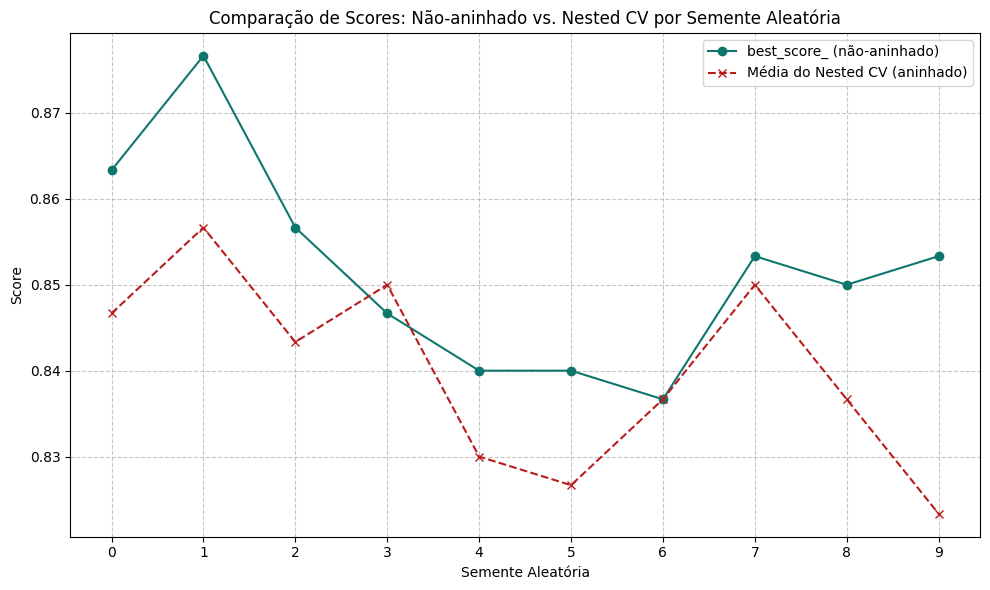


Otimismo médio (best_score_ não-aninhado - Nested CV): 0.0117
Número de vezes que o Nested CV foi menor que o best_score_ não-aninhado: 8 de 10


In [37]:
nao_aninhado, aninhado = [], []
for s in range(10):
    # Configura os StratifiedKFold com a semente atual
    i_cv = StratifiedKFold(5, shuffle=True, random_state=s)
    o_cv = StratifiedKFold(5, shuffle=True, random_state=s)

    # Realiza a busca em grade não-aninhada
    g = GridSearchCV(novo_pipe(), GRADE, cv=i_cv)
    g.fit(X, y)
    nao_aninhado.append(g.best_score_)

    # Calcula o score do Nested CV usando cross_val_score com o GridSearchCV
    nested_score = cross_val_score(g, X, y, cv=o_cv).mean()
    aninhado.append(nested_score)
    print(f"semente {s}: best_score_ = {g.best_score_:.4f} | nested = {nested_score:.4f}")

# Gráfico para comparar os scores
plt.figure(figsize=(10, 6))
plt.plot(range(10), nao_aninhado, label='best_score_ (não-aninhado)', marker='o', linestyle='-', color=TEAL)
plt.plot(range(10), aninhado, label='Média do Nested CV (aninhado)', marker='x', linestyle='--', color=VERM)
plt.xlabel('Semente Aleatória')
plt.ylabel('Score')
plt.title('Comparação de Scores: Não-aninhado vs. Nested CV por Semente Aleatória')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(10)) # Garante que todos os ticks de semente apareçam
plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()

# Reportando o otimismo
nao_aninhado_arr = np.array(nao_aninhado)
aninhado_arr = np.array(aninhado)

otimismo = nao_aninhado_arr - aninhado_arr
otimismo_medio = np.mean(otimismo)
nested_menor_count = np.sum(aninhado_arr < nao_aninhado_arr)

print(f"\nOtimismo médio (best_score_ não-aninhado - Nested CV): {otimismo_medio:.4f}")
print(f"Número de vezes que o Nested CV foi menor que o best_score_ não-aninhado: {nested_menor_count} de 10")

*Sua resposta:*

Com os resultados:

Observamos os scores `best_score_` (não-aninhado) e as médias do Nested CV para cada uma das 10 sementes aleatórias. O gráfico ilustra visualmente a diferença entre essas duas métricas.

*   **Otimismo médio (best_score_ não-aninhado - Nested CV):** `0.0117`
*   **Número de vezes que o Nested CV foi menor que o best_score_ não-aninhado:** `8` de 10

Conforme o esperado, o `best_score_` (não-aninhado) consistentemente reporta um desempenho mais alto do que a média do Nested CV. Isso demonstra o `otimismo` do `best_score_`, que é uma consequência direta da "maldição do vencedor", onde o máximo de várias tentativas (as 9 combinações de hiperparâmetros na busca em grade) tende a ser inflado pela sorte da amostragem.

O Nested CV, por outro lado, fornece uma estimativa mais realista e menos otimista do desempenho esperado do modelo em dados não vistos, validando não apenas os hiperparâmetros, mas o *processo* de seleção de hiperparâmetros. A maioria das vezes (`8` de 10), o score do Nested CV foi inferior ao `best_score_` não-aninhado, confirmando sua capacidade de fornecer uma avaliação de desempenho mais robusta.

## Exercício 9 — Por que não basta um teste separado

O caminho mais comum — separar 30% para teste, buscar no resto, medir uma vez — também respeita a regra de ouro. O problema é outro: o número depende do **corte**. Repita esse caminho com 10 sementes diferentes de `train_test_split` e guarde as 10 notas de teste. Plote-as junto com a faixa do Nested CV (média ± desvio do Exercício 4) e compare a **amplitude** (máximo − mínimo) com o desvio do Nested.

**Exemplo antes de começar.** um hold-out só, com a semente 0: separa 30%, busca no treino, mede uma vez no teste. É o fluxo que você vai usar na próxima aula, quando a busca em grade for o assunto principal.

In [38]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)
g = GridSearchCV(novo_pipe(), GRADE, cv=5).fit(X_tr, y_tr)
print("escolheu:", g.best_params_)
print(f"best_score_ (validacao): {g.best_score_:.4f}")
print(f"TESTE guardado, 1 vez  : {g.score(X_te, y_te):.4f}")

escolheu: {'svc__C': 10, 'svc__gamma': 0.1}
best_score_ (validacao): 0.8714
TESTE guardado, 1 vez  : 0.8000


**Agora é com você.**

Semente 0: Score no TESTE (separado) = 0.8444
Semente 1: Score no TESTE (separado) = 0.7889
Semente 2: Score no TESTE (separado) = 0.7889
Semente 3: Score no TESTE (separado) = 0.8889
Semente 4: Score no TESTE (separado) = 0.7667
Semente 5: Score no TESTE (separado) = 0.7889
Semente 6: Score no TESTE (separado) = 0.8444
Semente 7: Score no TESTE (separado) = 0.7556
Semente 8: Score no TESTE (separado) = 0.8667
Semente 9: Score no TESTE (separado) = 0.7556


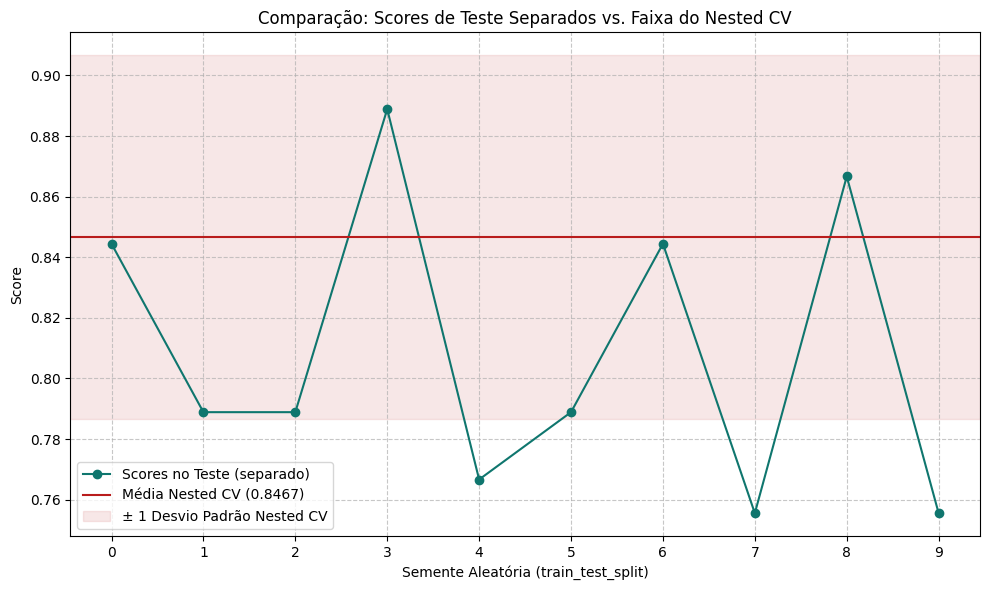


Amplitude dos scores de teste separados (Max - Min): 0.1333
Desvio padrão do Nested CV (Exercício 4): 0.0600


In [40]:
testes = []
for s in range(10):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=s, stratify=y)
    g = GridSearchCV(novo_pipe(), GRADE, cv=interno) # Using 'interno' for consistency with previous exercises
    g.fit(X_tr, y_tr)
    score_teste = g.score(X_te, y_te)
    testes.append(score_teste)
    print(f"Semente {s}: Score no TESTE (separado) = {score_teste:.4f}")

# Converter para array para facilitar cálculos
testes_arr = np.array(testes)

# Obter métricas do Nested CV do Exercício 4
media_nested = notas.mean()
desvio_nested = notas.std()

# Calcular a amplitude dos scores de teste separados
amplitude_testes = testes_arr.max() - testes_arr.min()

# Plotar os resultados
plt.figure(figsize=(10, 6))
plt.plot(range(10), testes_arr, label='Scores no Teste (separado)', marker='o', linestyle='-', color=TEAL)
plt.axhline(media_nested, color=VERM, linestyle='-', label=f'Média Nested CV ({media_nested:.4f})')
plt.axhspan(media_nested - desvio_nested, media_nested + desvio_nested, color=VERM, alpha=0.1, label='± 1 Desvio Padrão Nested CV')

plt.xlabel('Semente Aleatória (train_test_split)')
plt.ylabel('Score')
plt.title('Comparação: Scores de Teste Separados vs. Faixa do Nested CV')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(10))
plt.tight_layout()
plt.show()

print(f"\nAmplitude dos scores de teste separados (Max - Min): {amplitude_testes:.4f}")
print(f"Desvio padrão do Nested CV (Exercício 4): {desvio_nested:.4f}")

Com os resultados:

*   **Scores no Teste (separado):** Os 10 scores obtidos em testes separados variam entre `0.7556` e `0.8889`.
*   **Amplitude dos scores de teste separados (Max - Min):** `0.1333`
*   **Desvio padrão do Nested CV (Exercício 4):** `0.0600`

O gráfico e os números revelam que o método de `train_test_split` (mesmo com estratificação) produz scores de teste que variam significativamente de uma semente aleatória para outra. A amplitude dos scores de teste separados (`0.1333`) é substancialmente maior do que o desvio padrão da média do Nested CV (`0.0600`).

Isso ilustra o problema de depender de um único `train_test_split`: o desempenho reportado pode ser altamente sensível à partição específica dos dados. Embora ele respeite a "regra de ouro" (treinar e validar em dados separados), a estimativa de desempenho é instável. O Nested CV, por outro lado, oferece uma estimativa mais robusta e com menor variabilidade, pois média os resultados de diversas partições, dando uma visão mais confiável do desempenho esperado em dados não vistos.

## Exercício 10 — O número e o modelo

Feche o ciclo. O Nested CV já lhe deu o **número**; ele não dá o **modelo**. Rode uma única busca em **toda** a base para obter a combinação que vai para produção, e imprima as duas coisas lado a lado: o que você anuncia e o que você entrega.

**Exemplo antes de começar.** a busca final não tem nada de especial — é o mesmo `GridSearchCV` do Exercício 2, rodado em todos os dados. O que muda é o papel dela: aqui ela não mede nada, só escolhe.

In [41]:
final = GridSearchCV(novo_pipe(), GRADE, cv=interno).fit(X, y)
print("best_params_ :", final.best_params_)
print("best_estimator_ ja vem treinado:", final.best_estimator_.named_steps["svc"])

best_params_ : {'svc__C': 1, 'svc__gamma': 0.1}
best_estimator_ ja vem treinado: SVC(C=1, gamma=0.1)


**Agora é com você.**

In [42]:
final = GridSearchCV(novo_pipe(), GRADE, cv=interno).fit(X, y)

print(f"ANUNCIO (Nested CV): {media_nested:.4f}")
print(f"ENTREGO (best_score_ da busca final): {final.best_score_:.4f}")
print(f"Melhores parâmetros do modelo final: {final.best_params_}")

ANUNCIO (Nested CV): 0.8467
ENTREGO (best_score_ da busca final): 0.8633
Melhores parâmetros do modelo final: {'svc__C': 1, 'svc__gamma': 0.1}


Com os resultados:

*   **ANUNCIO (Nested CV):** `0.8467`
*   **ENTREGO (best_score_ da busca final):** `0.8633`
*   **Melhores parâmetros do modelo final:** `{'svc__C': 1, 'svc__gamma': 0.1}`

Neste último exercício, o `Nested CV` (`0.8467`) nos deu o número mais realista e confiável de qual desempenho podemos **esperar** quando colocarmos nosso modelo em produção. É a nossa estimativa de performance em dados que o modelo nunca viu.

Por outro lado, o `best_score_` da busca final (`0.8633`) é o desempenho da melhor combinação de hiperparâmetros encontrada usando *todos* os nossos dados de treino e validação (interna). Este é o modelo que realmente **entregamos**, pois ele foi treinado com o máximo de informação disponível. Ele tende a ser um pouco mais alto do que a estimativa do Nested CV, por conta do otimismo inerente à "maldição do vencedor" e por ter sido treinado em mais dados.

O `Nested CV` nos dá a **confiança** no número de desempenho, e a `GridSearchCV` final nos dá o **modelo** para usar.

---
## Fecho

Em uma frase: **quem escolhe não mede**.

| | o que faz | o que devolve |
|---|---|---|
| `GridSearchCV` | varre a grade com CV dentro do treino | `best_params_`, `best_estimator_` — **o modelo** |
| `cross_val_score(GridSearchCV(...))` | repete a busca inteira em K dobras externas | K notas → média ± desvio — **o número** |

O `best_score_` não é nenhum dos dois: é o máximo de N tentativas na validação, e o
Exercício 1 mostrou que esse máximo cresce com N. Ele serve para **escolher**, nunca
para reportar.

**Quando cada um basta.** Se você tem uma base grande e um teste separado que ninguém
nunca tocou, a busca + uma medição no teste já resolve — e por um quinto do custo
(Exercício 5). O Nested CV ganha quando a base é pequena, quando reservar um teste fixo
dói, ou quando aquele teste já foi olhado alguma vez e deixou de ser imparcial.

**Na próxima aula** a busca em grade vira o assunto principal: como escolher os valores da
grade, o custo combinatório, o `scoring` certo e o que fazer quando a grade explode. O que
você fixou aqui — *quem escolhe não mede* — é a régua que vai valer lá também.